## 1. Загрузите выборку из файла `gbm-data.csv` с помощью pandas и преобразуйте ее в массив numpy.

В первой колонке файла с данными записано, была или нет реакция. Все остальные колонки (d1 - d1776) содержат различные характеристики молекулы. Разбейте выборку на обучающую и тестовую, используя функцию `train_test_split` с параметрами `test_size = 0.8` и `random_state = 241`.

In [1]:
import pandas as pd
import numpy as np
from sklearn.metrics import log_loss
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
import matplotlib.pyplot as plt

data = pd.read_csv('gbm-data.csv')
x = data.drop('Activity', axis=1)
y = data['Activity']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.8, random_state=241)

## 2. Обучите `GradientBoostingClassifier` с параметрами `n_estimators=250`, `verbose=True`, `random_state=241` и для каждого значения `learning_rate` из списка [1, 0.5, 0.3, 0.2, 0.1] проделайте следующее:

- Используйте метод `staged_decision_function` для предсказания качества на обучающей и тестовой выборке на каждой итерации.
- Преобразуйте полученное предсказание по формуле `1 / (1 + e^(-y_pred))`, где `y_pred` — предсказанное значение.
- Вычислите и постройте график значений log-loss на обучающей и тестовой выборках, а также найдите минимальное значение метрики и номер итерации, на которой оно достигается.

      Iter       Train Loss   Remaining Time 
         1           1.0190            8.38s
         2           0.9192            8.08s
         3           0.8272            7.92s
         4           0.7834            7.83s
         5           0.7109            7.90s
         6           0.6368            7.86s


         7           0.5797            7.82s
         8           0.5610            7.77s
         9           0.5185            7.79s
        10           0.4984            7.77s


        20           0.1999            7.72s


        30           0.1313            7.44s


        40           0.0790            7.09s


...

        80           0.5242            5.64s


        90           0.4829            5.34s


       100           0.4473            5.05s


       200           0.2379            1.70s


0.1: min_log_loss = 0.5260639211584591, iteration = 52


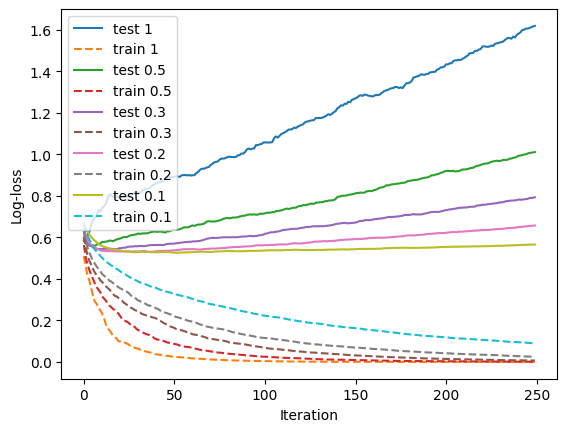

In [2]:
learning_rates = [1, 0.5, 0.3, 0.2, 0.1]
results = {}
plt.figure()
for lr in learning_rates:
    model = GradientBoostingClassifier(n_estimators=250, verbose=True, random_state=241, learning_rate=lr)
    model.fit(x_train, y_train)

    train_loss = []
    test_loss = []
    for train_decision, test_decision in zip(model.staged_decision_function(x_train), model.staged_decision_function(x_test)):
        train_probabilities = 1.0 / (1.0 + np.exp(-train_decision))
        test_probabilities = 1.0 / (1.0 + np.exp(-test_decision))
        train_loss.append(log_loss(y_train, train_probabilities))
        test_loss.append(log_loss(y_test, test_probabilities))

    min_loss = min(test_loss)
    best_iteration = test_loss.index(min_loss) + 1
    results[lr] = (min_loss, best_iteration)
    print(f'{lr}: min_log_loss = {min_loss}, iteration = {best_iteration}')
    plt.plot(test_loss, label=f'test {lr}')
    plt.plot(train_loss, '--', label=f'train {lr}')

plt.xlabel('Iteration')
plt.ylabel('Log-loss')
plt.legend()
plt.show()

## 3. Как можно охарактеризовать график качества на тестовой выборке, начиная с некоторой итерации: переобучение (overfitting) или недообучение (underfitting)?

В ответе укажите одно из слов `overfitting` либо `underfitting`.

In [3]:
print('Overfitting')

Overfitting


## 4. Приведите минимальное значение log-loss на тестовой выборке и номер итерации, на котором оно достигается, при `learning_rate = 0.2`.

In [4]:
print(f'{results[0.2][0]:.2f} {results[0.2][1]}')

0.53 37


## 5. На этих же данных обучите `RandomForestClassifier` с количеством деревьев, равным количеству итераций, на котором достигается наилучшее качество у градиентного бустинга из предыдущего пункта, `random_state=241` и остальными параметрами по умолчанию.

Какое значение log-loss на тесте получается у этого случайного леса? (Не забывайте, что предсказания нужно получать с помощью функции `predict_proba`. В данном случае брать сигмоиду от оценки вероятности класса не нужно.)

In [5]:
best_iteration = results[0.2][1]
random_forest = RandomForestClassifier(n_estimators=best_iteration, random_state=241)
random_forest.fit(x_train, y_train)
rf_probabilities = random_forest.predict_proba(x_test)[:, 1]
rf_log_loss = log_loss(y_test, rf_probabilities)

print(f'{rf_log_loss:.2f}')

0.54
